In [10]:
import matplotlib.image as image
import matplotlib.pyplot as plt
import numpy as np
import time
from numba import jit, cuda

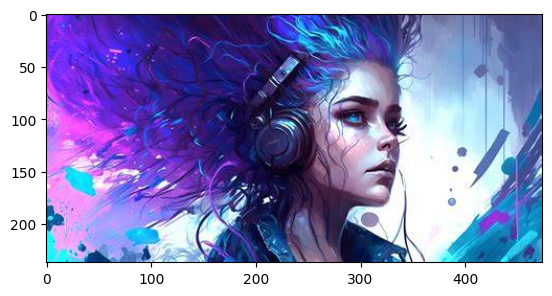

In [11]:
with open('./a.jpg', 'rb') as f:
    img = image.imread(f)
plt.imshow(img)
plt.show()

In [ ]:
height = img.shape[0]
width = img.shape[1]

cpu_gray_image = [
    [0 for _ in range(width)]
    for _ in range(height)
]

start = time.time()

for y in range(height):
    for x in range(width):
        r = int(img[y, x, 0])
        g = int(img[y, x, 1])
        b = int(img[y, x, 2])
        gray = (r + g + b) // 3
        cpu_gray_image[y][x] = gray

end = time.time()

print(f"CPU time: {end - start:.6f} seconds")

CPU time: 0.266899 seconds


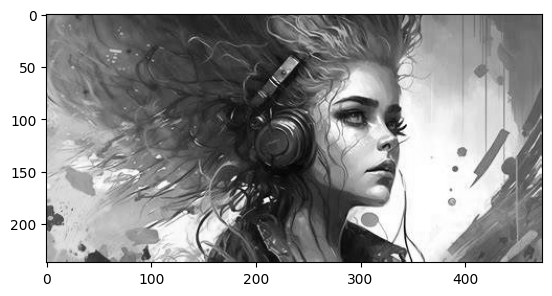

In [13]:
plt.imshow(cpu_gray_image, cmap='gray')

In [14]:
@cuda.jit
def grayscale_kernel(input_img, output_img):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    g = np.uint8((input_img[tidx, 0] + input_img[tidx, 1] + input_img[tidx, 2]) / 3)
    output_img[tidx, 0] = output_img[tidx, 1] = output_img[tidx, 2] = g

original_shape = img.shape
img_flat = img.reshape(-1, 3).astype(np.uint8)

d_img = cuda.to_device(img_flat)
d_grayscale_img = cuda.device_array(
    img_flat.shape,
    dtype=np.uint8
)
pixelCount = img_flat.shape[0]
blockSize = 256
gridSize = (pixelCount + blockSize - 1) // blockSize
start = time.time()
grayscale_kernel[gridSize, blockSize](d_img, d_grayscale_img)
cuda.synchronize()
end = time.time()
grayscale_img = d_grayscale_img.copy_to_host()
print(f"GPU time: {end - start:.6f} seconds")

GPU time: 0.056622 seconds


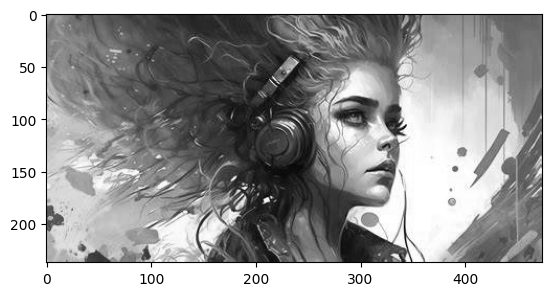

In [ ]:
plt.imshow(grayscale_img.reshape(original_shape))

Block Size:    1 | Grid Size:   112338 | Average Time: 0.8768 ms
Block Size:    2 | Grid Size:    56169 | Average Time: 0.4418 ms
Block Size:    4 | Grid Size:    28085 | Average Time: 0.2256 ms
Block Size:    8 | Grid Size:    14043 | Average Time: 0.1170 ms
Block Size:   16 | Grid Size:     7022 | Average Time: 0.0625 ms
Block Size:   32 | Grid Size:     3511 | Average Time: 0.0589 ms
Block Size:   64 | Grid Size:     1756 | Average Time: 0.0554 ms
Block Size:  128 | Grid Size:      878 | Average Time: 0.0546 ms
Block Size:  256 | Grid Size:      439 | Average Time: 0.0547 ms
Block Size:  512 | Grid Size:      220 | Average Time: 0.0549 ms
Block Size: 1024 | Grid Size:      110 | Average Time: 0.0677 ms


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 110 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Text(0.5, 1.0, 'CUDA Grayscale: Block Size vs Execution Time')

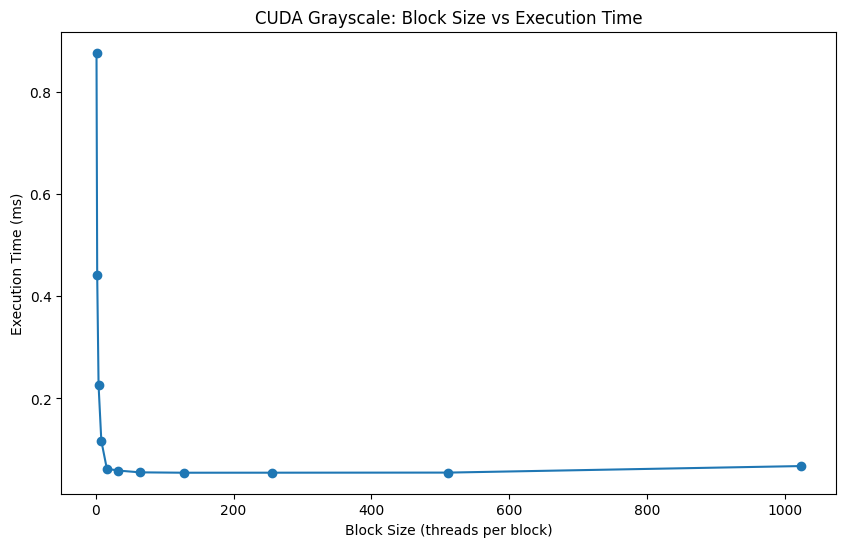

In [ ]:
# Different block sizes to test
block_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

times = []

# Number of measurements for each block size
num_runs = 20


# Warm-up CUDA JIT compilation
blockSize = 256
gridSize = (pixelCount + blockSize - 1) // blockSize

grayscale_kernel[gridSize, blockSize](
    d_img,
    d_grayscale_img
)

cuda.synchronize()

# Benchmark
for blockSize in block_sizes:

    gridSize = (pixelCount + blockSize - 1) // blockSize

    # Warm up this configuration
    grayscale_kernel[gridSize, blockSize](
        d_img,
        d_grayscale_img
    )
    cuda.synchronize()

    start = time.time()

    for _ in range(num_runs):
        grayscale_kernel[gridSize, blockSize](
            d_img,
            d_grayscale_img
        )

    cuda.synchronize()

    end = time.time()

    # Average execution time
    avg_time = (end - start) / num_runs

    times.append(avg_time)

    print(
        f"Block Size: {blockSize:4d} | "
        f"Grid Size: {gridSize:8d} | "
        f"Average Time: {avg_time * 1000:.4f} ms"
    )


# Copy final result back to CPU
grayscale_img = d_grayscale_img.copy_to_host()
grayscale_img = grayscale_img.reshape(original_shape)


# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    block_sizes,
    np.array(times) * 1000,
    marker="o"
)

plt.xlabel("Block Size (threads per block)")
plt.ylabel("Execution Time (ms)")
plt.title("CUDA Grayscale: Block Size vs Execution Time")